# Time Series Basic Project

Is project mein hum time series data ko samjhenge, visualize karenge aur simple forecasting karenge. 

## 📌 Step 1: Libraries Import Karna

Yahan hum woh libraries import karte hain jo data analysis aur plotting ke liye zaroori hain.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

## 📌 Step 2: Fake Time Series Data Banana

Hum yahan ek simple sales ka data bana rahe hain jo daily basis par change hota hai.

In [2]:
np.random.seed(42)

date_range = pd.date_range(start='2023-01-01', periods=60, freq='D')
sales = np.random.randint(200, 500, size=60) + np.linspace(0, 120, 60)

data = pd.DataFrame({'Date': date_range, 'Sales': sales})
data.set_index('Date', inplace=True)

data.head()

,Sales
Date,
2023-01-01,302.000000
2023-01-02,472.033898
2023-01-03,310.067797
2023-01-04,277.101695
2023-01-05,396.135593


## 📌 Step 3: Data Visualization

Ab hum graph bana kar dekhte hain ke sales ka trend kaisa hai.

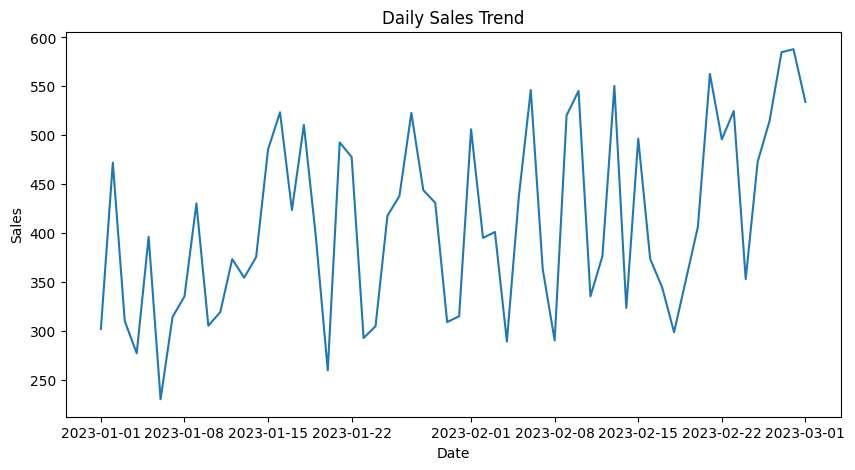

In [3]:
plt.figure(figsize=(10,5))
plt.plot(data['Sales'])
plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

## 📌 Step 4: Moving Average (Trend Smooth Karna)

Moving average ka matlab hota hai data ko smooth karna taake trend clear nazar aaye.

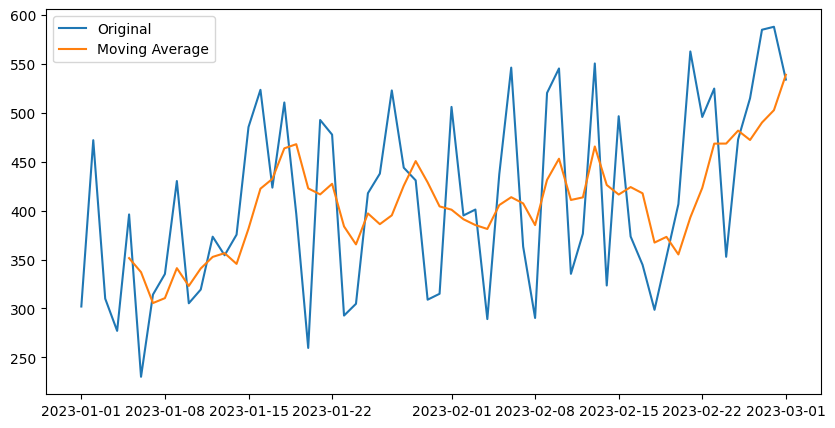

In [4]:
data['Moving_Avg'] = data['Sales'].rolling(window=5).mean()

plt.figure(figsize=(10,5))
plt.plot(data['Sales'], label='Original')
plt.plot(data['Moving_Avg'], label='Moving Average')
plt.legend()
plt.show()

## 📌 Step 5: Simple Forecasting (ARIMA Model)

Yahan hum future sales predict karne ki koshish karte hain.

In [5]:
model = ARIMA(data['Sales'], order=(2,1,2))
model_fit = model.fit()

forecast = model_fit.forecast(steps=10)
forecast

c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\PC\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


2023-03-02    493.350610
2023-03-03    503.443060
2023-03-04    512.093030
2023-03-05    509.152708
2023-03-06    507.368369
2023-03-07    508.172720
2023-03-08    508.526742
2023-03-09    508.316234
2023-03-10    508.249612
2023-03-11    508.302855
Freq: D, Name: predicted_mean, dtype: float64

## 📌 Step 6: Forecast Visualization

Ab hum predicted values ko graph par dekhte hain.

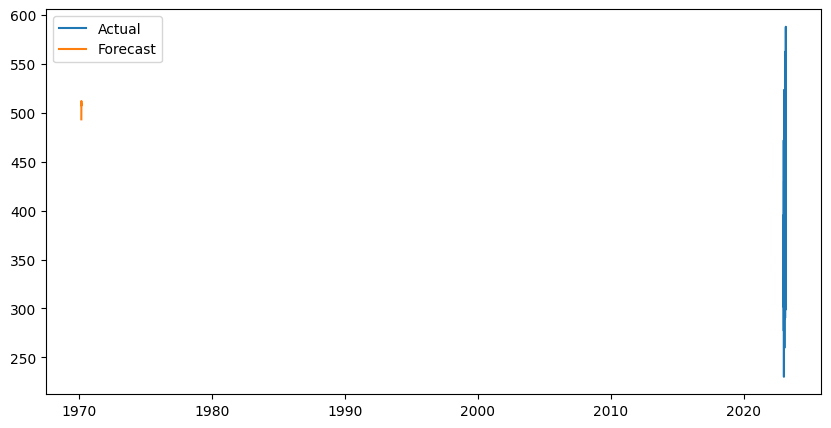

In [6]:
plt.figure(figsize=(10,5))
plt.plot(data['Sales'], label='Actual')
plt.plot(range(len(data), len(data)+10), forecast, label='Forecast')
plt.legend()
plt.show()